In [79]:
# TensorFlow and tf.keras
import tensorflow as tf
from tensorflow.keras.losses import SparseCategoricalCrossentropy

# Helper libraries
import numpy as np
import matplotlib.pyplot as plt

In [14]:
#in this task i use the Fashion MNIST dataset which contains 70,000 grayscale images in 10 categories.
# The images show individual articles of clothing at low resolution (28 by 28 pixels)
#datadir='https://github.com/zalandoresearch/fashion-mnist/tree/master/data/fashion'

In [15]:
#Loads the Fashion-MNIST dataset
fashion_mnist = tf.keras.datasets.fashion_mnist

#devide  fashion_mnist  into train and test sets.

(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()
fashion_mnist

<module 'keras.datasets.fashion_mnist' from '/usr/local/lib/python3.12/dist-packages/keras/datasets/fashion_mnist/__init__.py'>

# Explore the data

In [5]:
train_images

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

In [7]:
train_labels.shape
#so we have  60000 images those images represents in our datseta s arrays as beforev

(60000,)

In [9]:
train_labels #those label belongs to 10 groups or labels Each label is an integer between 0 and 9:

array([9, 0, 0, ..., 3, 0, 5], dtype=uint8)

In [27]:
#we check if the images will be as 28*28 shape
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

assert train_images.shape == (60000, 28, 28)
assert test_images.shape == (10000, 28, 28)
assert train_labels.shape == (60000,)
assert test_labels.shape == (10000,)

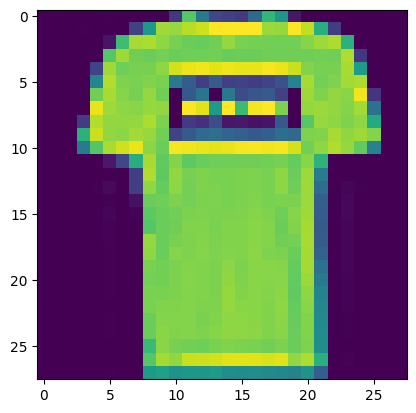

In [35]:
#show the images by drawing one image
plt.figure()
plt.imshow(train_images[1])#choose the second images
# plt.colorbar()#put the color bar bside the foto
# plt.grid(False)
plt.show()


# Preprocess the data

In [28]:
#we normalize the arrays whic represents the iamges by deviding them at 255
#to convert them between 0 and 1 because each cell in number between 0 and 255 as the scale of collors
train_images = train_images / 255.0

test_images = test_images / 255.0


In [38]:
#build  the name of the labels group
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


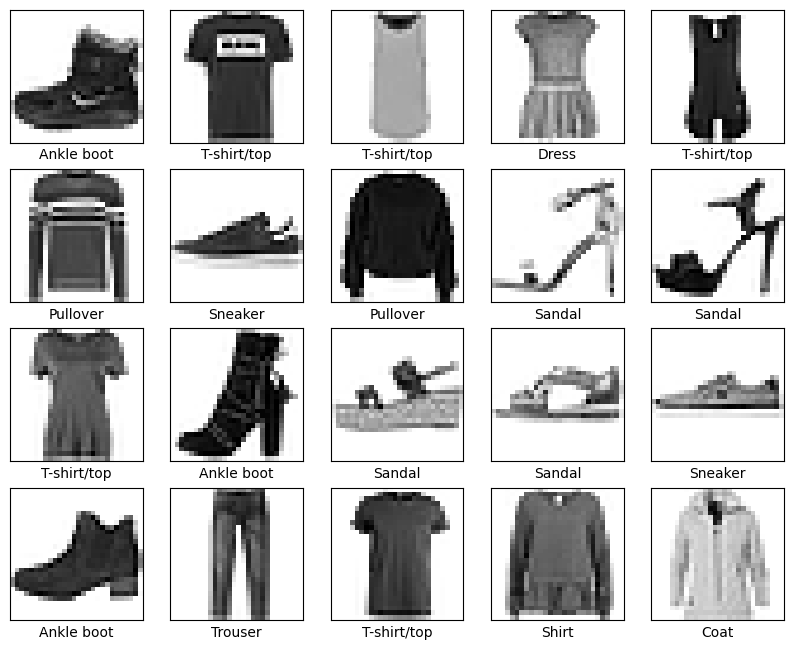

In [40]:
# we want to check the iamges is correct or not by ploting some of them as 20 images
plt.figure(figsize=(10,10))
for i in range(20):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    # plt.grid(False)
    plt.imshow(train_images[i], cmap=plt.cm.binary)
    plt.xlabel(class_names[train_labels[i]])
plt.show()


In [82]:
#because we want to use CNN which use 4D tensor so we must reshape those to 4 tonsors
#(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

X_train=train_images.reshape(train_images.shape[0],28,28,1)
X_test=test_images.reshape(test_images.shape[0],28,28,1)
y_train=train_labels.reshape(train_labels.shape[0],1)
Y_test=test_labels.reshape(test_labels.shape[0],1)

# Build the model

In [74]:

model2 = Sequential()

# 1. Convolutional Layer: Learns 32 different "filters" (features)
model2.add(Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))

# 2. Pooling Layer: Shrinks the image to make the model faster and more robust
model2.add(MaxPooling2D((2, 2)))

# 3. Second Convolutional Layer: Learns more complex patterns
model2.add(Conv2D(64, (3, 3), activation='relu'))
model2.add(MaxPooling2D((2, 2)))

# 4. The "Bridge": Flatten the 2D patterns into a 1D vector
model2.add(Flatten())

# 5. Fully Connected Layers: The same logic as your previous model
model2.add(Dense(128, activation='relu'))
model2.add(Dense(10, activation='softmax')) # Softmax for probability output

# Compile the model

In [75]:
model2.compile(optimizer='adam',
              loss=SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

# Train the model

In [76]:
model2.fit(train_images, train_labels, epochs=10)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/nn.py:1214: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 37s 19ms/step - accuracy: 0.8393 - loss: 0.4459
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 36s 19ms/step - accuracy: 0.8905 - loss: 0.2978
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 40s 19ms/step - accuracy: 0.9065 - loss: 0.2531
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 36s 19ms/step - accuracy: 0.9190 - loss: 0.2213
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 34s 18ms/step - accuracy: 0.9277 - loss: 0.1952
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 35s 19ms/step - accuracy: 0.9351 - loss: 0.1711
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 37s 20ms/step - accuracy: 0.9416 - loss: 0.1541
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 40s 21ms/step - accuracy: 0.9493 - loss: 0.1333
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 37s 20ms/step - accuracy: 0.9571 - loss: 0.1168
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 38s 20ms/step - accuracy: 0.9608 - loss: 0.1053


In [ ]:
# X_train=train_images.reshape(train_images.shape[0],28,28,1)
# X_test=test_images.reshape(test_images.shape[0],28,28,1)
# y_train=train_labels.reshape(train_labels.shape[0],1)
# Y_test=test_labels.reshape(test_labels.shape[0],1)

# accuracy: 0.9608 - loss: 0.1053  





In [85]:
test2_loss,test2_labels=model2.evaluate(X_test,Y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8263 - loss: 84.2984


In [86]:
ptredictionsCNN=model2.predict(test_images)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


In [87]:
np.argmax(ptredictionsCNN[2]) == test_labels[2]

np.True_

In [63]:
#Define functions to graph the full set of 10 class predictions.
def plot_image(i, predictions_array, true_label, img):
  true_label, img = true_label[i], img[i]
  plt.grid(False)
  plt.xticks([])
  plt.yticks([])

  plt.imshow(img, cmap=plt.cm.binary)

  predicted_label = np.argmax(predictions_array)
  if predicted_label == true_label:
    color = 'blue'
  else:
    color = 'red'

  plt.xlabel("{} {:2.0f}% ({})".format(class_names[predicted_label],
                                100*np.max(predictions_array),
                                class_names[true_label]),
                                color=color)

def plot_value_array(i, predictions_array, true_label):
  true_label = true_label[i]
  plt.grid(False)
  plt.xticks(range(10))
  plt.yticks([])
  thisplot = plt.bar(range(10), predictions_array, color="#777777")
  plt.ylim([0, 1])
  predicted_label = np.argmax(predictions_array)

  thisplot[predicted_label].set_color('red')
  thisplot[true_label].set_color('blue')


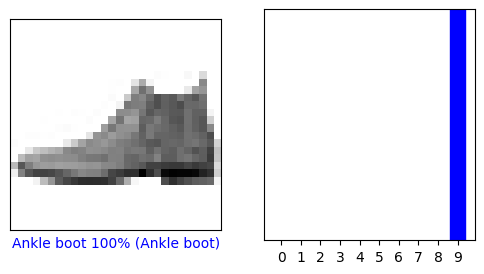

In [97]:
i = 0
plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plot_image(i, ptredictionsCNN[i], y_test, test_images)
plt.subplot(1,2,2)
plot_value_array(i, ptredictionsCNN[i],  y_test)
plt.show()

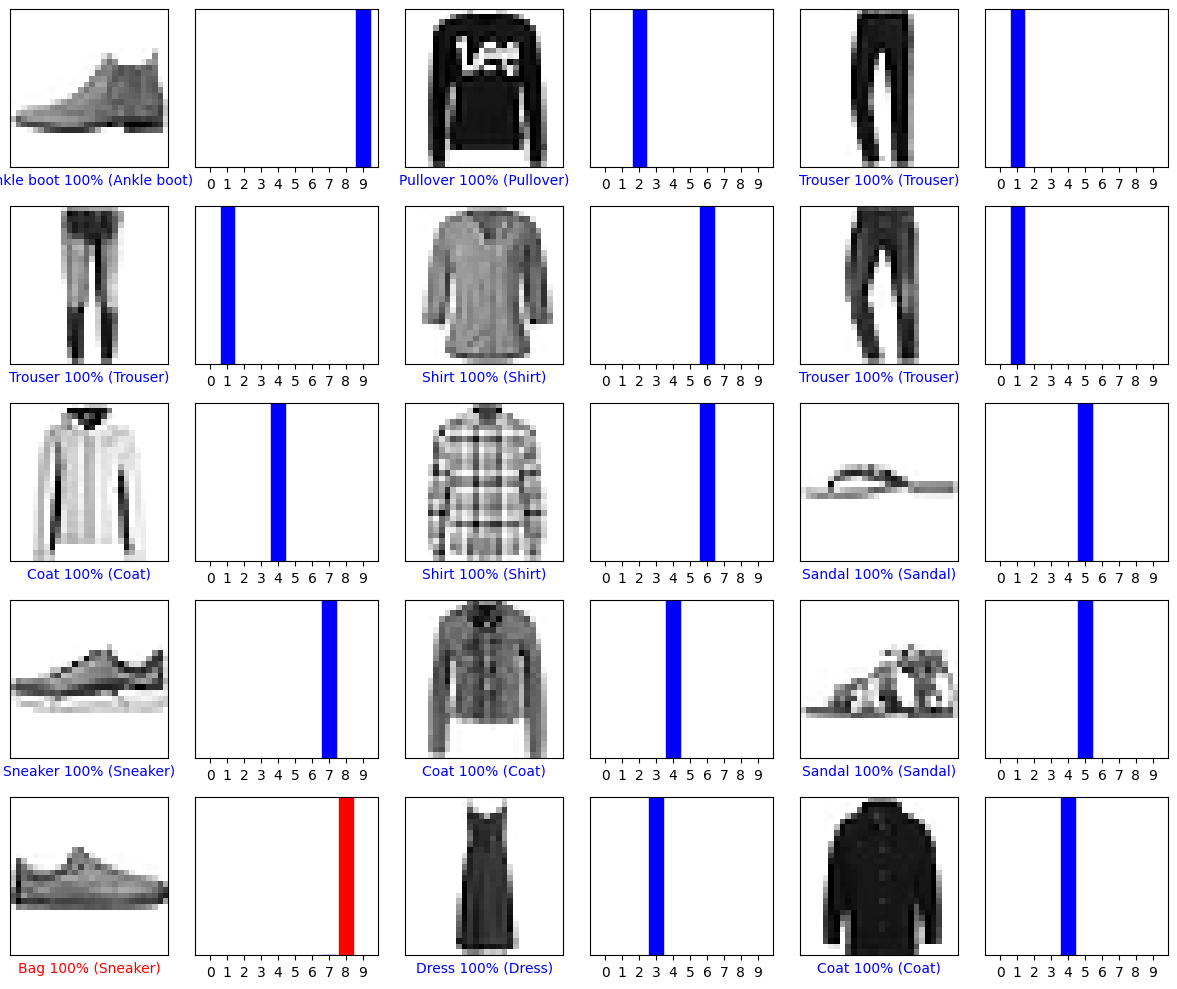

In [92]:
# Plot the first X test images, their predicted labels, and the true labels.
# Color correct predictions in blue and incorrect predictions in red.
num_rows = 5
num_cols = 3
num_images = num_rows*num_cols
plt.figure(figsize=(2*2*num_cols, 2*num_rows))
for i in range(num_images):
  plt.subplot(num_rows, 2*num_cols, 2*i+1)
  plot_image(i, ptredictionsCNN[i], y_test, test_images)
  plt.subplot(num_rows, 2*num_cols, 2*i+2)
  plot_value_array(i, ptredictionsCNN[i], y_test)
plt.tight_layout()
plt.show()
